In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("titanic.csv")

# Re-apply the same cleaning as 01_eda.ipynb, so this notebook works standalone
df = df.drop(columns=["deck"])
df = df.dropna(subset=["embarked", "embark_town"])

print(df.shape)
print(df["survived"].value_counts(normalize=True))

# NOTE: age is intentionally left with nulls here — it gets imputed
# inside the preprocessing pipeline in Task 8, fit on the training data only.

(889, 14)
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


In [2]:
X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True))

Train shape: (711, 13) Test shape: (178, 13)

Train class balance:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Test class balance:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


### Stratified train/test split

The overall dataset has a class imbalance: about 61.7% did not survive and 38.3%
survived. A plain random split could, by chance, produce a train or test set with a
noticeably different balance, which would make evaluation metrics less reliable and
could bias training. Using `stratify=y` in `train_test_split` ensures both the train
and test sets preserve this same ~62/38 split, which is confirmed in the output
above (train: 61.7%/38.3%, test: 61.8%/38.2%).

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["age", "fare", "sibsp", "parch", "pclass"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42, max_depth=4))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("All three models trained.")

All three models trained.


In [7]:
import matplotlib.pyplot as plt

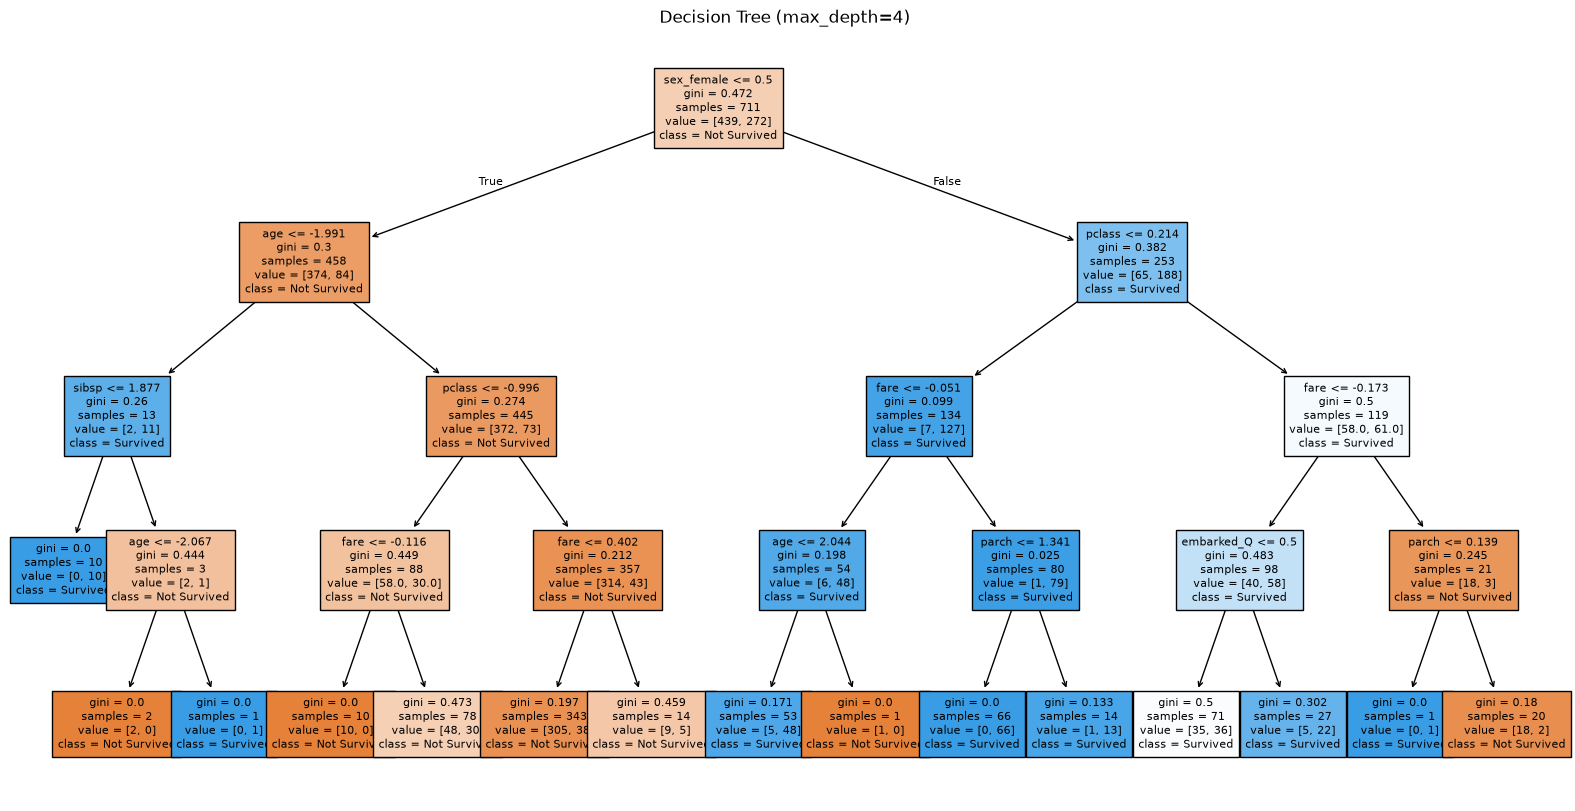

In [8]:
from sklearn.tree import plot_tree

feature_names = (
    numeric_features +
    list(tree_pipeline.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .named_steps["encoder"]
         .get_feature_names_out(categorical_features))
)

plt.figure(figsize=(20, 10))
plot_tree(
    tree_pipeline.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    fontsize=8
)
plt.title("Decision Tree (max_depth=4)")
plt.savefig("decision_tree.png")
plt.show()

In [9]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

models = {
    "Logistic Regression": log_reg_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline
}

results = []
roc_data = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)

    print(f"=== {name} ===")
    print("Confusion matrix:\n", cm)
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}\n")

    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1": f1, "AUC": auc
    })

comparison_df = pd.DataFrame(results)
print(comparison_df)

=== Logistic Regression ===
Confusion matrix:
 [[97 13]
 [21 47]]
Accuracy: 0.8090 | Precision: 0.7833 | Recall: 0.6912 | F1: 0.7344 | AUC: 0.8610

=== Decision Tree ===
Confusion matrix:
 [[100  10]
 [ 24  44]]
Accuracy: 0.8090 | Precision: 0.8148 | Recall: 0.6471 | F1: 0.7213 | AUC: 0.8560

=== Random Forest ===
Confusion matrix:
 [[96 14]
 [18 50]]
Accuracy: 0.8202 | Precision: 0.7812 | Recall: 0.7353 | F1: 0.7576 | AUC: 0.8215

                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.808989   0.783333  0.691176  0.734375  0.860963
1        Decision Tree  0.808989   0.814815  0.647059  0.721311  0.856016
2        Random Forest  0.820225   0.781250  0.735294  0.757576  0.821457


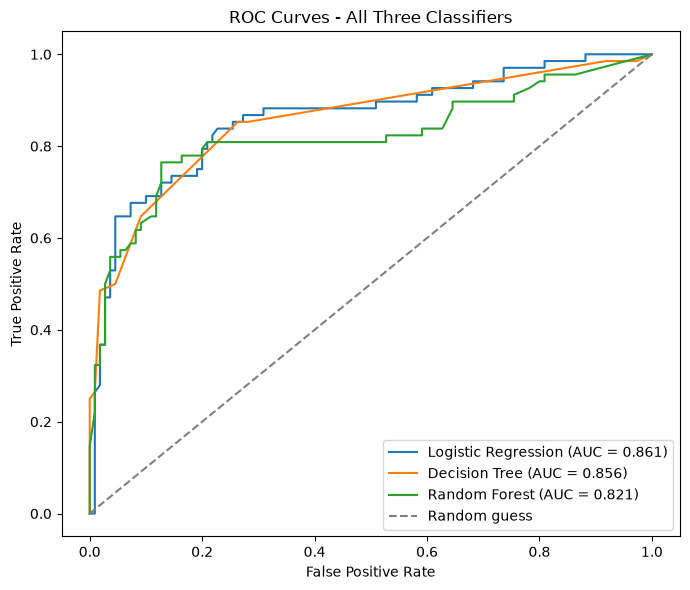

In [10]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Three Classifiers")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png")
plt.show()

### Model evaluation (Task 10)

All three classifiers were trained on the identical stratified split and evaluated
on the held-out test set:

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.809 | 0.783 | 0.691 | 0.734 | 0.861 |
| Decision Tree | 0.809 | 0.815 | 0.647 | 0.721 | 0.856 |
| Random Forest | 0.820 | 0.781 | 0.735 | 0.758 | 0.821 |

Random Forest has the highest accuracy and F1, and the best recall (fewest missed
survivors), but the lowest AUC of the three. Logistic Regression has the best AUC,
meaning it ranks predicted survival probabilities best overall, even though its
recall is lower than Random Forest's at the default 0.5 threshold. Decision Tree
has the best precision but the weakest recall, meaning it is more conservative
about predicting survival.

In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score

class_balance = y.value_counts(normalize=True)
print("Overall class balance:\n", class_balance)

imbalance_results = []

# (a) baseline
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
baseline_pipeline.fit(X_train, y_train)
pred_a = baseline_pipeline.predict(X_test)
imbalance_results.append({
    "Strategy": "Baseline (no handling)",
    "Precision": precision_score(y_test, pred_a),
    "Recall": recall_score(y_test, pred_a),
    "F1": f1_score(y_test, pred_a)
})

# (b) class_weight='balanced'
balanced_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])
balanced_pipeline.fit(X_train, y_train)
pred_b = balanced_pipeline.predict(X_test)
imbalance_results.append({
    "Strategy": "class_weight='balanced'",
    "Precision": precision_score(y_test, pred_b),
    "Recall": recall_score(y_test, pred_b),
    "F1": f1_score(y_test, pred_b)
})

# (c) SMOTE, applied to the training fold only
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_transformed, y_train)

smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
pred_c = smote_model.predict(X_test_transformed)
imbalance_results.append({
    "Strategy": "SMOTE (train fold only)",
    "Precision": precision_score(y_test, pred_c),
    "Recall": recall_score(y_test, pred_c),
    "F1": f1_score(y_test, pred_c)
})

imbalance_df = pd.DataFrame(imbalance_results)
print(imbalance_df)

Overall class balance:
 survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64
                  Strategy  Precision    Recall        F1
0   Baseline (no handling)   0.783333  0.691176  0.734375
1  class_weight='balanced'   0.718310  0.750000  0.733813
2  SMOTE (train fold only)   0.735294  0.735294  0.735294


### Imbalance handling comparison (Task 11)

Overall class balance: 61.8% did not survive, 38.2% survived — a moderate imbalance.

| Strategy | Precision | Recall | F1 |
|---|---|---|---|
| Baseline (no handling) | 0.783 | 0.691 | 0.734 |
| class_weight='balanced' | 0.718 | 0.750 | 0.734 |
| SMOTE (train fold only) | 0.735 | 0.735 | 0.735 |

All three strategies land at nearly the same F1 (0.733-0.735), so no strategy is a
dramatic winner here — the imbalance is moderate rather than severe, which limits
how much these techniques can move the needle. The baseline has the highest
precision but the lowest recall, meaning it misses more actual survivors. Both
`class_weight='balanced'` and SMOTE trade some precision for higher recall, and
SMOTE gives the most balanced result, with precision and recall equal at 0.735 and
the highest F1 of the three (marginally). Given that recall matters here — correctly
identifying survivors — I would prefer SMOTE or class_weight='balanced' over the
baseline, with SMOTE having a very slight edge on F1.

In [12]:
from sklearn.model_selection import GridSearchCV

rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(oob_score=True, random_state=42))
])

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(rf_tuning_pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
print("OOB score:", best_rf.named_steps["classifier"].oob_score_)

Best parameters: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
Best CV F1 score: 0.7420434551195058
OOB score: 0.8087201125175809


### Hyperparameter tuning (Task 12)

GridSearchCV was run over `n_estimators` ([100, 200, 300]), `max_depth` ([None, 5, 10]),
and `max_features` (['sqrt', 'log2']) on the Random Forest, using 5-fold
cross-validation with F1 as the scoring metric, and `oob_score=True` set at
construction.

Best parameters: `max_depth=5`, `max_features='sqrt'`, `n_estimators=100`
Best cross-validated F1 score: 0.742
Out-of-bag (OOB) score: 0.809

The best model uses a fairly shallow tree depth (5), which suggests deeper trees
were overfitting to the training data without improving generalization. The OOB
score (0.809), calculated internally from the training data left out of each
tree's bootstrap sample, is a reasonable independent estimate of test performance
and is close to the untuned Random Forest's test accuracy from Task 10 (0.820).

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_numeric_features = ["age", "sibsp", "parch", "pclass"]
reg_categorical_features = ["sex", "embarked"]

reg_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), reg_numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), reg_categorical_features)
])

X_reg = df[reg_numeric_features + reg_categorical_features]
y_reg = df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])
reg_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = reg_pipeline.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = mean_squared_error(y_reg_test, y_reg_pred) ** 0.5
r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = X_reg_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

MAE: 21.1398
RMSE: 41.7465
R2: 0.3468
Adjusted R2: 0.3239


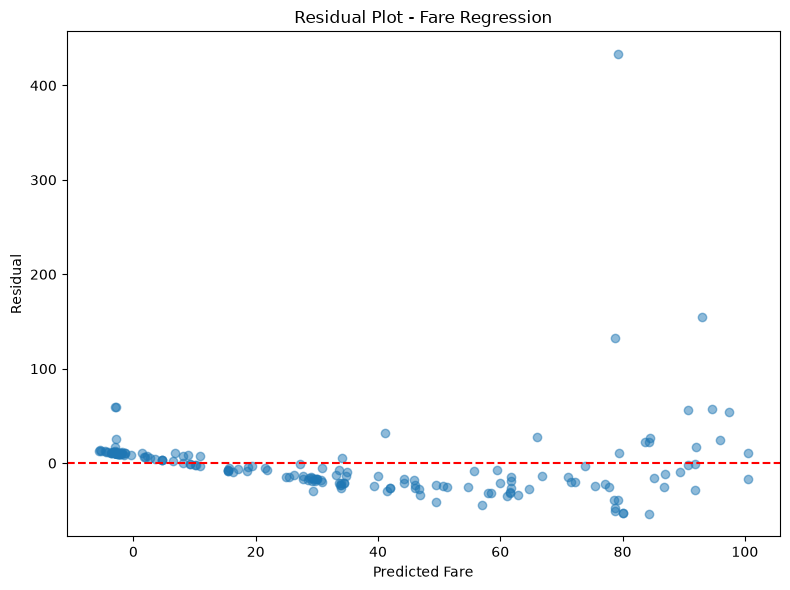

In [14]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_reg_pred, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot - Fare Regression")
plt.tight_layout()
plt.savefig("residual_plot.png")
plt.show()

### Regression side-task (Task 13)

Predicting `fare` from the other available features (age, sibsp, parch, pclass,
sex, embarked) using multivariate linear regression:

| Metric | Value |
|---|---|
| MAE | 21.14 |
| RMSE | 41.75 |
| R² | 0.347 |
| Adjusted R² | 0.324 |

The R² of 0.347 means the model explains only about 35% of the variance in fare —
these features (mostly pclass and family size) capture some of the pattern in fare
but leave much of it unexplained, likely because fare within a class also depends
on cabin location, discounts, and other factors not present in this dataset.

The residual plot shows clear heteroscedasticity: residuals are small and tightly
clustered near zero at low predicted fares, but the spread grows substantially at
higher predicted fares, including a large outlier residual near a predicted fare of
80. This funnel-shaped, non-random spread violates the constant-variance assumption
of linear regression, which is unsurprising given how right-skewed the original
fare distribution is (as shown in the Part A EDA).

In [15]:
print("=== Classification models ===")
print(comparison_df.to_string(index=False))

print("\n=== Regression model ===")
regression_summary = pd.DataFrame([{
    "Model": "Linear Regression (fare prediction)",
    "MAE": mae, "RMSE": rmse, "R2": r2, "Adjusted R2": adj_r2
}])
print(regression_summary.to_string(index=False))

=== Classification models ===
              Model  Accuracy  Precision   Recall       F1      AUC
Logistic Regression  0.808989   0.783333 0.691176 0.734375 0.860963
      Decision Tree  0.808989   0.814815 0.647059 0.721311 0.856016
      Random Forest  0.820225   0.781250 0.735294 0.757576 0.821457

=== Regression model ===
                              Model       MAE      RMSE       R2  Adjusted R2
Linear Regression (fare prediction) 21.139829 41.746517 0.346773     0.323853


### Final model comparison and recommendation (Task 14)

**Classification models**

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.809 | 0.783 | 0.691 | 0.734 | 0.861 |
| Decision Tree | 0.809 | 0.815 | 0.647 | 0.721 | 0.856 |
| Random Forest | 0.820 | 0.781 | 0.735 | 0.758 | 0.821 |

**Regression model**

| Model | MAE | RMSE | R2 | Adjusted R2 |
|---|---|---|---|---|
| Linear Regression (fare) | 21.14 | 41.75 | 0.347 | 0.324 |

Note: classification and regression metrics are on different scales and are not
directly comparable — they are shown as two separate groups above.

**Recommendation:** I would deploy the Random Forest model. It has the highest
accuracy (0.820) and the highest F1 score (0.758) of the three classifiers, and
its recall (0.735) is meaningfully better than both Logistic Regression (0.691) and
the Decision Tree (0.647) — meaning it misses fewer actual survivors, which matters
more than a small loss in precision for a problem like this. Logistic Regression
does have the highest AUC (0.861 vs 0.821), showing it ranks predicted probabilities
slightly better overall, but at the standard 0.5 decision threshold, Random Forest's
balance of precision and recall is the strongest of the three. Combined with the
GridSearchCV tuning results (Task 12), which confirmed a shallow, regularized Random
Forest generalizes well (OOB score 0.809, close to its test accuracy of 0.820),
Random Forest is the model I would take forward for deployment.

In [16]:
import joblib

# best_rf is the tuned Random Forest pipeline from Task 12 (GridSearchCV's best_estimator_)
# It already includes the full preprocessor + classifier as one Pipeline object.
joblib.dump(best_rf, "best_titanic_pipeline.joblib")
print("Pipeline saved.")

# Reload and test on raw, unprocessed input
loaded_pipeline = joblib.load("best_titanic_pipeline.joblib")

sample_raw = X_test.iloc[:5]
original_preds = best_rf.predict(sample_raw)
reloaded_preds = loaded_pipeline.predict(sample_raw)

print("Original model predictions:", original_preds)
print("Reloaded model predictions:", reloaded_preds)
print("Match:", (original_preds == reloaded_preds).all())

Pipeline saved.
Original model predictions: [0 0 0 0 0]
Reloaded model predictions: [0 0 0 0 0]
Match: True
